## Características de los archivos FITS

Los archivos FITS (Flexible Image Transport System) son el formato estándar en astronomía para almacenar y transmitir datos científicos. Algunas características clave:

- **Estructura**: Pueden contener múltiples extensiones (HDUs - Header Data Units)
- **Cabecera**: Metadatos en formato texto (clave-valor) que describen los datos
- **Datos**: Normalmente arrays multidimensionales (2D para imágenes)
- **Soporte**: Mantenido por la NASA y ampliamente usado en astronomía



=== Información DUD ===
Tamaño original: (43, 43)
Tipo de datos: >f4
Valores: min=-0.03, max=2.28

=== Información ACS ===
Tamaño: (147, 147)
Tipo de datos: >f4
Valores: min=-0.03, max=0.21

=== Después del resize ===
Nuevo tamaño DUD: (147, 147)
Valores redimensionados: min=-0.02, max=2.28


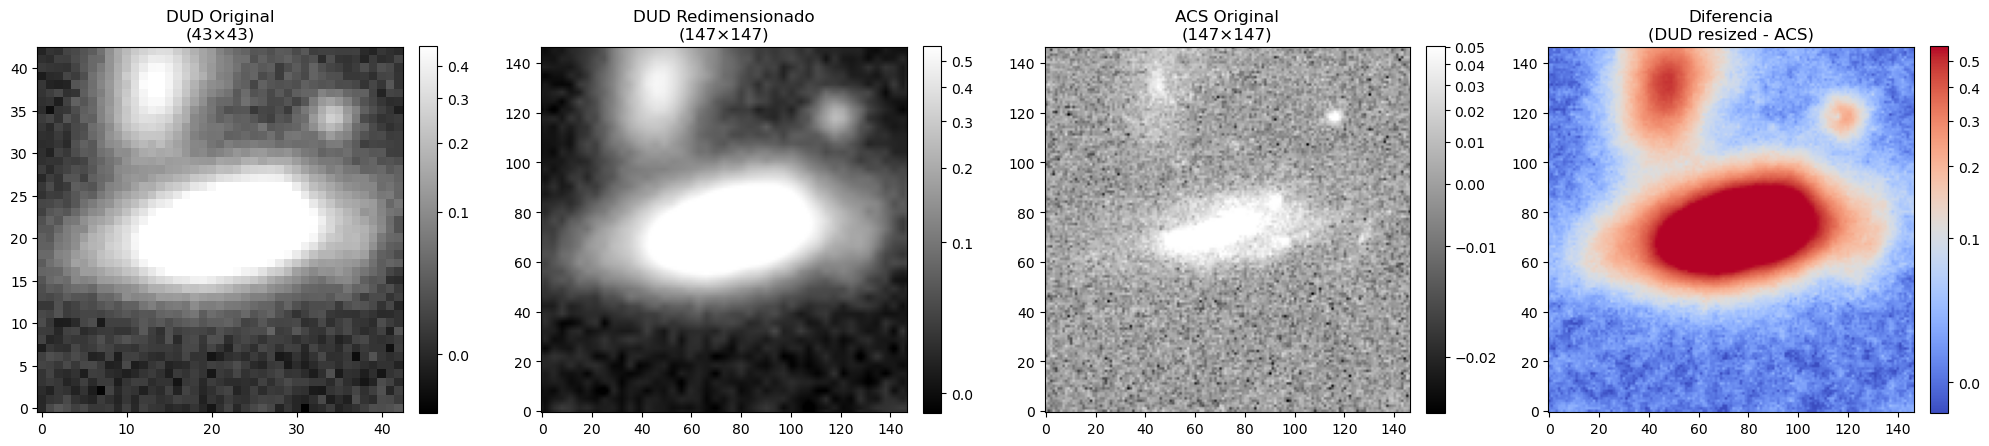

In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import (ImageNormalize, AsinhStretch, ZScaleInterval)
import numpy as np
import os
from skimage.transform import resize

def load_compare_display(dud_path, acs_path):
    # Verificar que los archivos existen
    if not os.path.exists(dud_path):
        print(f"Error: El archivo DUD no existe en {dud_path}")
        return
    if not os.path.exists(acs_path):
        print(f"Error: El archivo ACS no existe en {acs_path}")
        return
    
    try:
        # Cargar los archivos FITS
        with fits.open(dud_path) as dud_hdul:
            # Obtener los datos de la primera extensión con datos válidos
            dud_data = None
            for hdu in dud_hdul:
                if hdu.data is not None and hdu.data.size > 1:  # Buscar la primera extensión con datos de imagen
                    dud_data = hdu.data
                    dud_header = hdu.header
                    break
            
            if dud_data is None:
                print("Error: No se encontraron datos válidos en el archivo DUD")
                return
            
            print("\n=== Información DUD ===")
            print(f"Tamaño original: {dud_data.shape}")
            print(f"Tipo de datos: {dud_data.dtype}")
            print(f"Valores: min={np.nanmin(dud_data):.2f}, max={np.nanmax(dud_data):.2f}")
        
        with fits.open(acs_path) as acs_hdul:
            # Obtener los datos de la primera extensión con datos válidos
            acs_data = None
            for hdu in acs_hdul:
                if hdu.data is not None and hdu.data.size > 1:  # Buscar la primera extensión con datos de imagen
                    acs_data = hdu.data
                    acs_header = hdu.header
                    break
            
            if acs_data is None:
                print("Error: No se encontraron datos válidos en el archivo ACS")
                return
            
            print("\n=== Información ACS ===")
            print(f"Tamaño: {acs_data.shape}")
            print(f"Tipo de datos: {acs_data.dtype}")
            print(f"Valores: min={np.nanmin(acs_data):.2f}, max={np.nanmax(acs_data):.2f}")
        
        # Redimensionar la imagen DUD para que coincida con ACS
        dud_resized = resize(dud_data, acs_data.shape, 
                            mode='reflect',  # Método de extrapolación
                            anti_aliasing=True,  # Aplicar anti-aliasing
                            preserve_range=True)  # Mantener el rango de valores original
        
        print("\n=== Después del resize ===")
        print(f"Nuevo tamaño DUD: {dud_resized.shape}")
        print(f"Valores redimensionados: min={np.nanmin(dud_resized):.2f}, max={np.nanmax(dud_resized):.2f}")
        
        # Configurar la visualización
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
        
        # Normalización para las imágenes
        norm_dud = ImageNormalize(dud_data, interval=ZScaleInterval(), stretch=AsinhStretch())
        norm_acs = ImageNormalize(acs_data, interval=ZScaleInterval(), stretch=AsinhStretch())
        norm_dud_resized = ImageNormalize(dud_resized, interval=ZScaleInterval(), stretch=AsinhStretch())
        
        # Mostrar imágenes originales
        im1 = ax1.imshow(dud_data, origin='lower', cmap='gray', norm=norm_dud)
        ax1.set_title('DUD Original\n(43×43)')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        
        im2 = ax2.imshow(dud_resized, origin='lower', cmap='gray', norm=norm_dud_resized)
        ax2.set_title('DUD Redimensionado\n(147×147)')
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        
        im3 = ax3.imshow(acs_data, origin='lower', cmap='gray', norm=norm_acs)
        ax3.set_title('ACS Original\n(147×147)')
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        
        # Calcular y mostrar diferencia
        diff = dud_resized - acs_data
        norm_diff = ImageNormalize(diff, interval=ZScaleInterval(), stretch=AsinhStretch())
        im4 = ax4.imshow(diff, origin='lower', cmap='coolwarm', norm=norm_diff)
        ax4.set_title('Diferencia\n(DUD resized - ACS)')
        plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        plt.show()
        
        return dud_resized, acs_data
    
    except Exception as e:
        print(f"\nError al procesar los archivos FITS: {str(e)}")
        return None, None

# Rutas a los archivos
dud_file = "../data/raw/dud/n1/n1_0_141190.fits"
acs_file = "../data/raw/acs/n1/n1_0_141190_ACS.fits"

# Ejecutar la función
dud_resized, acs_data = load_compare_display(dud_file, acs_file)

In [3]:
import os
from astropy.io import fits
import numpy as np
from tqdm import tqdm

def safe_fits_open(filepath):
    """Intenta abrir un archivo FITS y devolver copia de los datos válidos"""
    try:
        with fits.open(filepath) as hdul:
            data_list = [hdu.data for hdu in hdul if hdu.data is not None and hdu.data.size > 1]
            return data_list if data_list else None
    except (OSError, IOError):
        return None


def analyze_datasets(base_path):
    # Definir las rutas base
    dud_base = os.path.join(base_path, "raw", "dud")
    acs_base = os.path.join(base_path, "raw", "acs")
    
    # Resultados por categoría
    results = {
        'n1': {'matches': 0, 'dud_only': 0, 'acs_only': 0, 'dud_corrupt': 0, 'acs_corrupt': 0},
        'n2': {'matches': 0, 'dud_only': 0, 'acs_only': 0, 'dud_corrupt': 0, 'acs_corrupt': 0}
    }
    
    # Estadísticas adicionales
    stats = {
        'n1': {'dud_counts': [], 'acs_counts': []},
        'n2': {'dud_counts': [], 'acs_counts': []}
    }
    
    for category in ['n1', 'n2']:
        print(f"\nProcesando categoría {category}...")
        
        # Rutas completas
        dud_path = os.path.join(dud_base, category)
        acs_path = os.path.join(acs_base, category)
        
        # Obtener listados de archivos
        try:
            dud_files = [f for f in os.listdir(dud_path) if f.endswith('.fits')]
            print(f"  - Encontrados {len(dud_files)} archivos en DUD/{category}")
        except FileNotFoundError:
            dud_files = []
            print(f"  - Advertencia: No se encontró la carpeta DUD/{category}")
        
        try:
            acs_files = [f for f in os.listdir(acs_path) if f.endswith('.fits')]
            print(f"  - Encontrados {len(acs_files)} archivos en ACS/{category}")
        except FileNotFoundError:
            acs_files = []
            print(f"  - Advertencia: No se encontró la carpeta ACS/{category}")
        
        # Convertir a conjuntos para búsqueda eficiente
        dud_set = set(dud_files)
        acs_set = set(acs_files)
        
        # Procesar archivos DUD con barra de progreso
        for dud_file in tqdm(dud_files, desc=f"Procesando DUD/{category}"):
            dud_filepath = os.path.join(dud_path, dud_file)
            dud_hdul = safe_fits_open(dud_filepath)
            
            if dud_hdul is None:
                results[category]['dud_corrupt'] += 1
                continue
                
            expected_acs_file = dud_file.replace('.fits', '_ACS.fits')
            acs_filepath = os.path.join(acs_path, expected_acs_file)
            acs_hdul = safe_fits_open(acs_filepath)
            
            if acs_hdul is None:
                results[category]['dud_only'] += 1
                continue
                
            # Tenemos una pareja válida
            results[category]['matches'] += 1
            
            # Obtener datos y calcular estadísticas
            for data in dud_hdul:
                if data is not None and data.size > 1:
                    stats[category]['dud_counts'].append(np.nansum(data))
                    break

            
            for data in acs_hdul:
                if data is not None and data.size > 1:
                    stats[category]['acs_counts'].append(np.nansum(data))
                    break

        
        # Procesar archivos ACS que no tienen pareja en DUD
        for acs_file in tqdm(acs_files, desc=f"Procesando ACS/{category}"):
            expected_dud_file = acs_file.replace('_ACS.fits', '.fits')
            if expected_dud_file not in dud_set:
                acs_filepath = os.path.join(acs_path, acs_file)
                acs_hdul = safe_fits_open(acs_filepath)
                
                if acs_hdul is None:
                    results[category]['acs_corrupt'] += 1
                else:
                    results[category]['acs_only'] += 1
    
    # Mostrar resultados detallados
    print("\n=== Resumen de correspondencia de archivos ===")
    for category in ['n1', 'n2']:
        print(f"\nCategoría {category.upper()}:")
        print(f"  - Archivos DUD analizados: {results[category]['matches'] + results[category]['dud_only'] + results[category]['dud_corrupt']}")
        print(f"  - Archivos ACS analizados: {results[category]['matches'] + results[category]['acs_only'] + results[category]['acs_corrupt']}")
        print(f"\n  - Parejas válidas encontradas: {results[category]['matches']}")
        print(f"  - Archivos DUD sin pareja: {results[category]['dud_only']}")
        print(f"  - Archivos ACS sin pareja: {results[category]['acs_only']}")
        print(f"  - Archivos DUD corruptos/vacíos: {results[category]['dud_corrupt']}")
        print(f"  - Archivos ACS corruptos/vacíos: {results[category]['acs_corrupt']}")
        
        if results[category]['matches'] > 0:
            print("\n  Estadísticas de las parejas encontradas:")
            print(f"  - Suma total de píxeles (DUD):")
            print(f"    Media: {np.mean(stats[category]['dud_counts']):.2f}")
            print(f"    Mediana: {np.median(stats[category]['dud_counts']):.2f}")
            print(f"    Mín: {np.min(stats[category]['dud_counts']):.2f}")
            print(f"    Máx: {np.max(stats[category]['dud_counts']):.2f}")
            
            print(f"\n  - Suma total de píxeles (ACS):")
            print(f"    Media: {np.mean(stats[category]['acs_counts']):.2f}")
            print(f"    Mediana: {np.median(stats[category]['acs_counts']):.2f}")
            print(f"    Mín: {np.min(stats[category]['acs_counts']):.2f}")
            print(f"    Máx: {np.max(stats[category]['acs_counts']):.2f}")
            
            # Calcular relación DUD/ACS
            ratios = np.array(stats[category]['dud_counts']) / np.array(stats[category]['acs_counts'])
            print(f"\n  - Relación DUD/ACS:")
            print(f"    Media: {np.mean(ratios):.2f}")
            print(f"    Mediana: {np.median(ratios):.2f}")
            print(f"    Mín: {np.min(ratios):.2f}")
            print(f"    Máx: {np.max(ratios):.2f}")
    
    return results, stats

# Ejecutar el análisis
base_path = "../data"
results, stats = analyze_datasets(base_path)


Procesando categoría n1...
  - Encontrados 11000 archivos en DUD/n1
  - Encontrados 8453 archivos en ACS/n1


Procesando ACS/n1: 100%|██████████| 8453/8453 [00:00<00:00, 3860038.29it/s]



Procesando categoría n2...
  - Encontrados 11000 archivos en DUD/n2
  - Encontrados 7661 archivos en ACS/n2


Procesando ACS/n2: 100%|██████████| 7661/7661 [00:00<00:00, 4074633.90it/s]


=== Resumen de correspondencia de archivos ===

Categoría N1:
  - Archivos DUD analizados: 11000
  - Archivos ACS analizados: 8453

  - Parejas válidas encontradas: 8453
  - Archivos DUD sin pareja: 2547
  - Archivos ACS sin pareja: 0
  - Archivos DUD corruptos/vacíos: 0
  - Archivos ACS corruptos/vacíos: 0

  Estadísticas de las parejas encontradas:
  - Suma total de píxeles (DUD):
    Media: 203.88
    Mediana: 62.06
    Mín: 2.22
    Máx: 32165.33

  - Suma total de píxeles (ACS):
    Media: 80.42
    Mediana: 25.81
    Mín: -74.76
    Máx: 9820.26

  - Relación DUD/ACS:
    Media: 2.44
    Mediana: 2.42
    Mín: -11.26
    Máx: 81.97

Categoría N2:
  - Archivos DUD analizados: 11000
  - Archivos ACS analizados: 7661

  - Parejas válidas encontradas: 7661
  - Archivos DUD sin pareja: 3339
  - Archivos ACS sin pareja: 0
  - Archivos DUD corruptos/vacíos: 0
  - Archivos ACS corruptos/vacíos: 0

  Estadísticas de las parejas encontradas:
  - Suma total de píxeles (DUD):
    Media: 189

In [4]:
import os
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def analyze_datasets(base_path):
    # Definir las rutas base
    dud_base = os.path.join(base_path, "raw", "dud")
    acs_base = os.path.join(base_path, "raw", "acs")
    
    # Resultados por categoría
    results = {
        'n1': {'matches': 0, 'dud_only': 0, 'acs_only': 0},
        'n2': {'matches': 0, 'dud_only': 0, 'acs_only': 0}
    }
    
    # Estadísticas adicionales
    stats = {
        'n1': {'dud_counts': [], 'acs_counts': []},
        'n2': {'dud_counts': [], 'acs_counts': []}
    }
    
    for category in ['n1', 'n2']:
        # Rutas completas
        dud_path = os.path.join(dud_base, category)
        acs_path = os.path.join(acs_base, category)
        
        # Obtener listados de archivos
        try:
            dud_files = [f for f in os.listdir(dud_path) if f.endswith('.fits')]
        except FileNotFoundError:
            dud_files = []
            print(f"Advertencia: No se encontró la carpeta DUD {category}")
        
        try:
            acs_files = [f for f in os.listdir(acs_path) if f.endswith('.fits')]
        except FileNotFoundError:
            acs_files = []
            print(f"Advertencia: No se encontró la carpeta ACS {category}")
        
        # Convertir a conjuntos para búsqueda eficiente
        dud_set = set(dud_files)
        acs_set = set(acs_files)
        
        # Encontrar coincidencias
        for dud_file in dud_files:
            expected_acs_file = dud_file.replace('.fits', '_ACS.fits')
            if expected_acs_file in acs_set:
                try:
                    # Leer ambos archivos
                    dud_value = None
                    acs_value = None
                    
                    with fits.open(os.path.join(dud_path, dud_file)) as dud_hdul:
                        for hdu in dud_hdul:
                            if hdu.data is not None and hdu.data.size > 1:
                                dud_value = np.nansum(hdu.data)
                                break
            
                    with fits.open(os.path.join(acs_path, expected_acs_file)) as acs_hdul:
                        for hdu in acs_hdul:
                            if hdu.data is not None and hdu.data.size > 1:
                                acs_value = np.nansum(hdu.data)
                                break
                    
                    # Solo si ambos valores se leyeron correctamente
                    if dud_value is not None and acs_value is not None:
                        results[category]['matches'] += 1
                        stats[category]['dud_counts'].append(dud_value)
                        stats[category]['acs_counts'].append(acs_value)
                    else:
                        raise ValueError("Datos vacíos en uno de los archivos")
                
                except Exception as e:
                    print(f"Error al procesar pareja {dud_file} / {expected_acs_file} -> {e}")
                    # Contamos el que sí existe
                    if dud_value is not None:
                        results[category]['dud_only'] += 1
                    elif acs_value is not None:
                        results[category]['acs_only'] += 1
                    else:
                        # Si fallaron los dos
                        results[category]['dud_only'] += 1
                        results[category]['acs_only'] += 1
            else:
                results[category]['dud_only'] += 1
        
        # Encontrar archivos solo en ACS
        for acs_file in acs_files:
            expected_dud_file = acs_file.replace('_ACS.fits', '.fits')
            if expected_dud_file not in dud_set:
                results[category]['acs_only'] += 1
    
    # Mostrar resultados
    print("\n=== Resumen de correspondencia de archivos ===")
    for category in ['n1', 'n2']:
        print(f"\nCategoría {category.upper()}:")
        print(f"  - Parejas encontradas: {results[category]['matches']}")
        print(f"  - Archivos solo en DUD: {results[category]['dud_only']}")
        print(f"  - Archivos solo en ACS: {results[category]['acs_only']}")
        
        if results[category]['matches'] > 0:
            print("\n  Estadísticas de las parejas encontradas:")
            print(f"  - Suma total de píxeles (DUD):")
            print(f"    Media: {np.mean(stats[category]['dud_counts']):.2f}")
            print(f"    Mediana: {np.median(stats[category]['dud_counts']):.2f}")
            print(f"    Mín: {np.min(stats[category]['dud_counts']):.2f}")
            print(f"    Máx: {np.max(stats[category]['dud_counts']):.2f}")
            
            print(f"\n  - Suma total de píxeles (ACS):")
            print(f"    Media: {np.mean(stats[category]['acs_counts']):.2f}")
            print(f"    Mediana: {np.median(stats[category]['acs_counts']):.2f}")
            print(f"    Mín: {np.min(stats[category]['acs_counts']):.2f}")
            print(f"    Máx: {np.max(stats[category]['acs_counts']):.2f}")
            
            # Calcular relación DUD/ACS
            ratios = np.array(stats[category]['dud_counts']) / np.array(stats[category]['acs_counts'])
            print(f"\n  - Relación DUD/ACS:")
            print(f"    Media: {np.mean(ratios):.2f}")
            print(f"    Mediana: {np.median(ratios):.2f}")
            print(f"    Mín: {np.min(ratios):.2f}")
            print(f"    Máx: {np.max(ratios):.2f}")
    
    return results, stats

# Ejecutar el análisis
base_path = "../data"
results, stats = analyze_datasets(base_path)


=== Resumen de correspondencia de archivos ===

Categoría N1:
  - Parejas encontradas: 8453
  - Archivos solo en DUD: 2547
  - Archivos solo en ACS: 0

  Estadísticas de las parejas encontradas:
  - Suma total de píxeles (DUD):
    Media: 203.88
    Mediana: 62.06
    Mín: 2.22
    Máx: 32165.33

  - Suma total de píxeles (ACS):
    Media: 80.42
    Mediana: 25.81
    Mín: -74.76
    Máx: 9820.26

  - Relación DUD/ACS:
    Media: 2.44
    Mediana: 2.42
    Mín: -11.26
    Máx: 81.97

Categoría N2:
  - Parejas encontradas: 7661
  - Archivos solo en DUD: 3339
  - Archivos solo en ACS: 0

  Estadísticas de las parejas encontradas:
  - Suma total de píxeles (DUD):
    Media: 189.05
    Mediana: 58.43
    Mín: 1.70
    Máx: 27268.63

  - Suma total de píxeles (ACS):
    Media: 75.12
    Mediana: 24.70
    Mín: -72.12
    Máx: 10665.23

  - Relación DUD/ACS:
    Media: 2.37
    Mediana: 2.41
    Mín: -304.54
    Máx: 21.05


In [5]:
from astropy.io import fits

print("DUD:")
with fits.open("../data/raw/dud/n1/n1_0_141190.fits") as hdul:
    print(hdul[0].header)  # O puedes usar un for para recorrer todos los HDUs

print("\n\n\nACS:")
with fits.open("../data/raw/acs/n1/n1_0_141190_ACS.fits") as hdul:
    print(hdul[0].header)  # O puedes usar un for para recorrer todos los HDUs

DUD:
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H COMMENT DAS Cutout version 200424                                               HIERARCH variance_scale = 1.38232237686498                                      BGMEAN  =   0.0128057485766347                                                  BGVAR   =  0.00503386633462228                                                  HIERARCH EXPINFO_V = 1                                                          AR_HDU  =                    5 / HDU (1-indexed) containing the archive used to HIERARCH TRANSMISSION_CURVE_ID = 1 

Procesando archivos...


Procesando n2: 100%|██████████| 11000/11000 [00:13<00:00, 836.59it/s]



Estadísticas globales:
Valor mínimo: -7.353157043457031
Valor máximo: 366.3216857910156
Media: 0.3318808078765869
Moda aproximada (a 7 decimales): 0.009640900418162346


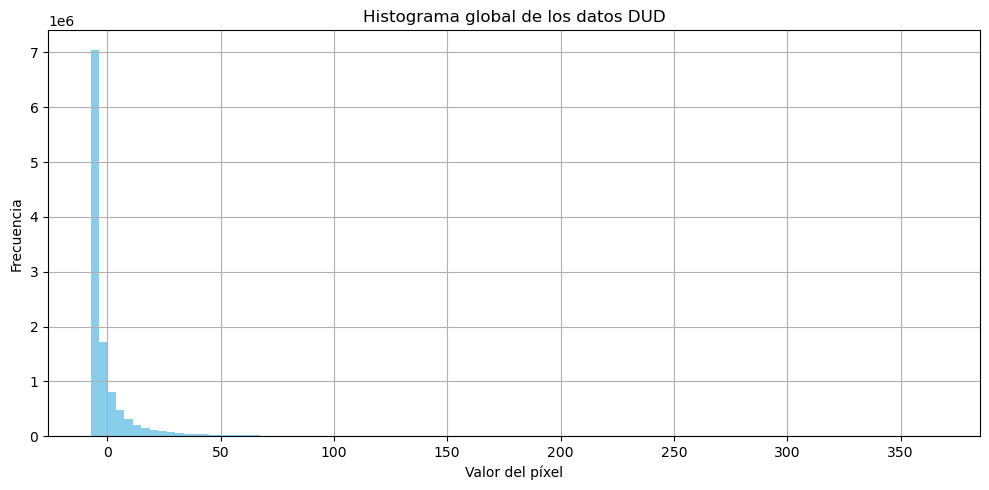

In [6]:
import os
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# Ruta base
base_path = "../data/raw/dud/"
subdirs = ["n1", "n2"]

# Inicializamos variables para estadísticas
min_val = np.inf
max_val = -np.inf
sum_vals = 0
count_vals = 0
hist_bins = 100  # puedes ajustar esto si hace falta
hist_range = None  # calculamos después
hist_total = None
value_counter = Counter()

# Recorremos todos los archivos
print("Procesando archivos...")
for subdir in subdirs:
    dir_path = os.path.join(base_path, subdir)
    files = [f for f in os.listdir(dir_path) if f.endswith('.fits')]

    for file in tqdm(files, desc=f"Procesando {subdir}"):
        file_path = os.path.join(dir_path, file)

        try:
            with fits.open(file_path, memmap=True) as hdul:
                for hdu in hdul:
                    if hdu.data is not None:
                        data = hdu.data.astype(np.float32).flatten()
                        data = data[np.isfinite(data)]  # eliminar NaNs o infinitos

                        # Estadísticas simples
                        min_val = min(min_val, data.min())
                        max_val = max(max_val, data.max())
                        sum_vals += data.sum()
                        count_vals += data.size

                        # Histograma incremental
                        if hist_range is None:
                            hist_range = (data.min(), data.max())

                        hist, _ = np.histogram(data, bins=hist_bins, range=hist_range)
                        hist_total = hist if hist_total is None else hist_total + hist

                        # Moda aproximada (más frecuente valor redondeado)
                        rounded = np.round(data, 7)  # precisión a 3 decimales
                        value_counter.update(rounded)

        except Exception as e:
            print(f"Error procesando {file_path}: {e}")

# Resultados finales
mean_val = sum_vals / count_vals
mode_val = value_counter.most_common(1)[0][0]

print(f"\nEstadísticas globales:")
print(f"Valor mínimo: {min_val}")
print(f"Valor máximo: {max_val}")
print(f"Media: {mean_val}")
print(f"Moda aproximada (a 7 decimales): {mode_val}")

hist_range = (min_val, max_val)  # <-- clave
bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins + 1)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

plt.figure(figsize=(10, 5))
plt.bar(bin_centers, hist_total, width=bin_edges[1] - bin_edges[0], color='skyblue')
plt.title("Histograma global de los datos DUD")
plt.xlabel("Valor del píxel")
plt.ylabel("Frecuencia")
plt.grid(True)
# plt.yscale("log")  # descomenta si quieres ver detalles en valores bajos
plt.tight_layout()
plt.show()

Procesando archivos...


Procesando n2: 100%|██████████| 7661/7661 [00:27<00:00, 274.98it/s]



Estadísticas globales:
Valor mínimo: -5.457014560699463
Valor máximo: 136.9979248046875
Media: 0.011310909874737263
Moda aproximada (a 7 decimales): 0.0014915999490767717


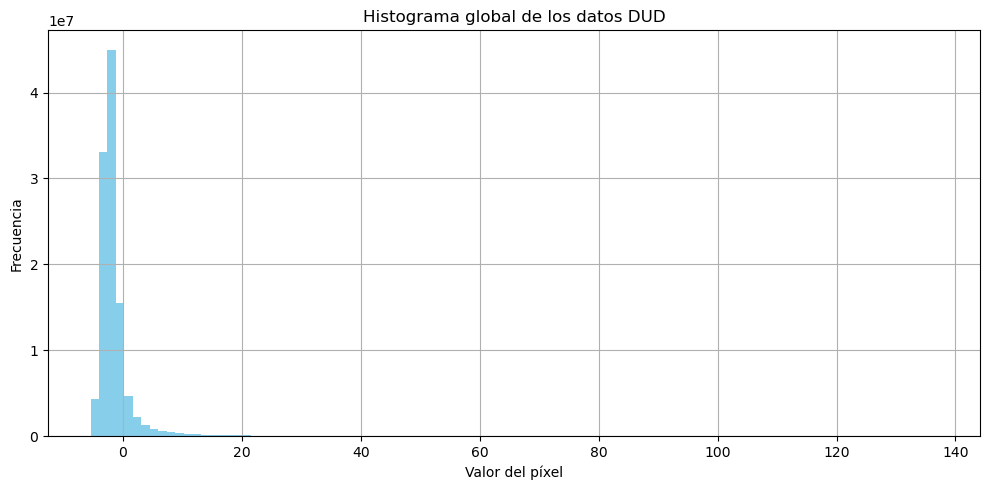

In [7]:
import os
import numpy as np
from astropy.io import fits
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

# Directorio raíz para los archivos ACS
base_path = "../data/raw/acs/"
subdirs = ['n1', 'n2']

# Inicializamos variables para estadísticas
min_val = np.inf
max_val = -np.inf
sum_vals = 0
count_vals = 0
hist_bins = 100  # puedes ajustar esto si hace falta
hist_range = None  # calculamos después
hist_total = None
value_counter = Counter()

# Recorremos todos los archivos
print("Procesando archivos...")
for subdir in subdirs:
    dir_path = os.path.join(base_path, subdir)
    files = [f for f in os.listdir(dir_path) if f.endswith('.fits')]

    for file in tqdm(files, desc=f"Procesando {subdir}"):
        file_path = os.path.join(dir_path, file)

        try:
            with fits.open(file_path, memmap=True) as hdul:
                for hdu in hdul:
                    if hdu.data is not None:
                        data = hdu.data.astype(np.float32).flatten()
                        data = data[np.isfinite(data)]  # eliminar NaNs o infinitos

                        # Estadísticas simples
                        min_val = min(min_val, data.min())
                        max_val = max(max_val, data.max())
                        sum_vals += data.sum()
                        count_vals += data.size

                        # Histograma incremental
                        if hist_range is None:
                            hist_range = (data.min(), data.max())

                        hist, _ = np.histogram(data, bins=hist_bins, range=hist_range)
                        hist_total = hist if hist_total is None else hist_total + hist

                        # Moda aproximada (más frecuente valor redondeado)
                        rounded = np.round(data, 7)  # precisión a 3 decimales
                        value_counter.update(rounded)

        except Exception as e:
            print(f"Error procesando {file_path}: {e}")
            # Determinar subcarpeta de origen (n1 o n2)
            subdir_corrupt = os.path.basename(os.path.dirname(file_path))
            destino_dir = os.path.join(base_path, "Corruptos", subdir_corrupt)

            # Crear carpeta si no existe
            os.makedirs(destino_dir, exist_ok=True)

            # Ruta de destino completa
            destino_path = os.path.join(destino_dir, file)

            # Mover archivo
            try:
                shutil.move(file_path, destino_path)
                print(f"Archivo movido a {destino_path}")
            except Exception as move_error:
                print(f"Error al mover {file_path}: {move_error}")

# Resultados finales
mean_val = sum_vals / count_vals
mode_val = value_counter.most_common(1)[0][0]

print(f"\nEstadísticas globales:")
print(f"Valor mínimo: {min_val}")
print(f"Valor máximo: {max_val}")
print(f"Media: {mean_val}")
print(f"Moda aproximada (a 7 decimales): {mode_val}")

# Histograma
hist_range = (min_val, max_val)  # <-- clave
bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins + 1)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

plt.figure(figsize=(10, 5))
plt.bar(bin_centers, hist_total, width=bin_edges[1] - bin_edges[0], color='skyblue')
plt.title("Histograma global de los datos DUD")
plt.xlabel("Valor del píxel")
plt.ylabel("Frecuencia")
plt.grid(True)
# plt.yscale("log")  # descomenta si quieres ver detalles en valores bajos
plt.tight_layout()
plt.show()

In [9]:
from astropy.io import fits

ruta = '../data/raw/acs/n1/n10_0_87915_ACS.fits'
with fits.open(ruta) as hdul:
    data = hdul[0].data
    print(data.shape)
    print(data)


(34, 34)
[[ 0.02160637  0.00063047  0.00780596 ...  0.00355878  0.0092645
   0.02680666]
 [ 0.00400506 -0.00142104 -0.00344201 ...  0.009839    0.01586364
   0.03671426]
 [-0.00470971 -0.00235314  0.009006   ...  0.02060303  0.01648168
   0.05721563]
 ...
 [ 0.00743475  0.00335963 -0.0024312  ... -0.00119656 -0.00221307
   0.0002405 ]
 [ 0.01279362  0.01660694  0.00645192 ...  0.00200139  0.00407316
   0.00307457]
 [ 0.00971672  0.00491422  0.0057808  ...  0.01453981  0.0006086
   0.00557383]]
